In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('titanic_data_updated.csv')
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.shape

print(f"Total potential features :{df.shape[1]}")
print(f"Total sample data :{df.shape[0]}")

Total potential features :12
Total sample data :891


In [8]:
df.head(10)
df.sample(23)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
13,14,no,third,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
558,559,yes,first,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
477,478,no,third,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,NaN,S
525,526,no,third,"Farrell, Mr. James",male,40.5,0,0,367232,7.7500,NaN,Q
248,249,yes,first,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S
764,765,no,third,"Eklund, Mr. Hans Linus",male,16.0,0,0,347074,7.7750,NaN,S
244,245,no,third,"Attalah, Mr. Sleiman",male,30.0,0,0,2694,7.2250,NaN,C
826,827,no,third,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S
575,576,no,third,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
340,341,yes,second,"Navratil, Master. Edmond Roger",male,2.0,1,1,230080,26.0000,F2,S


feature screening

In [12]:
df.isnull() # null na tkle false show korbe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df.duplicated() # naiee


,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [16]:
df.duplicated().sum() #$duplicated naieee

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

statistical profiling

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [19]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


  Univariate Analysis( Categorical Value Analysis -1 )

<Axes: xlabel='Survived', ylabel='count'>

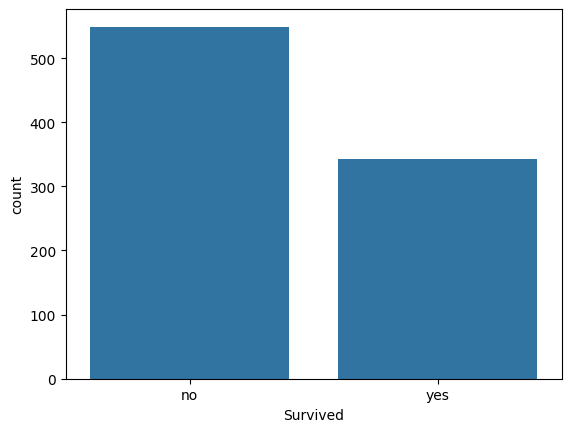

In [24]:
sns.countplot(data=df,x='Survived')

# DATA=DF   bolei disi

#sns.countplot(data = df , x=df['Survived'])

In [25]:
df['Survived'].value_counts()

,count
Survived,
no,549
yes,342


In [26]:
(df['Survived'].value_counts()/len(df))*100

,count
Survived,
no,61.616162
yes,38.383838


In [28]:
df['Survived'].unique()

array(['no', 'yes'], dtype=object)

In [30]:
df['Survived'].value_counts()

,count
Survived,
no,549
yes,342


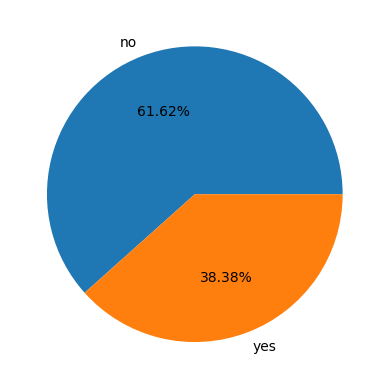

In [35]:
survived_count =df['Survived'].value_counts()
survived_label = df['Survived'].unique()
plt.pie(survived_count, labels=survived_label , autopct='%1.2f%%')
#direct df dia bosate paro like df['Survived'].value_counts()... labels use korte hbe pie e
plt.show()

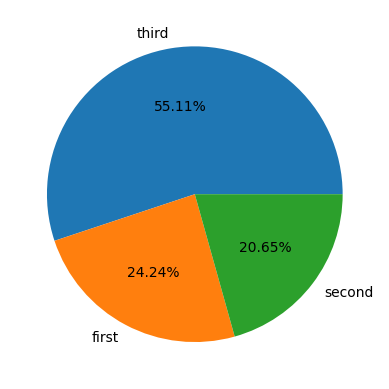

In [44]:
counts = df['Pclass'].value_counts()
labelss = df['Pclass'].unique()
plt.pie(counts , labels=labelss , autopct='%1.2f%%')
plt.show()

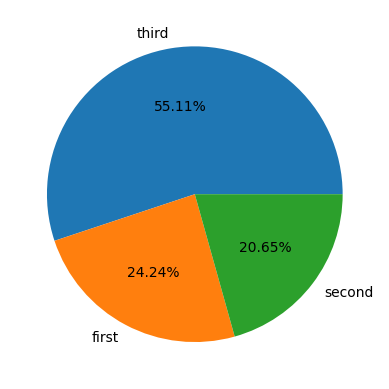

In [43]:
df['Pclass'].value_counts()
df['Pclass'].unique()
plt.pie(df['Pclass'].value_counts(), labels=df['Pclass'].unique(), autopct='%1.2f%%')
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

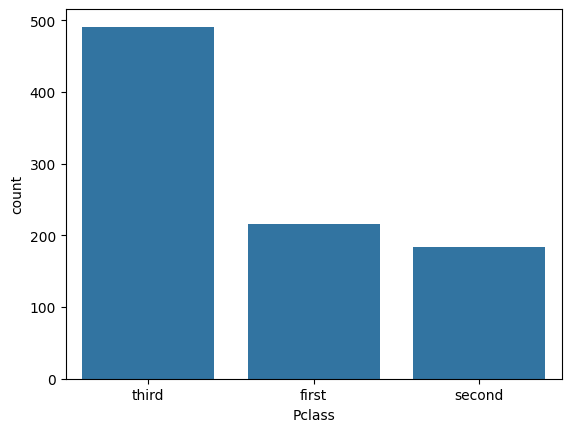

In [46]:
sns.countplot(data = df,x=df['Pclass'])
# y axis e k koiber ase set ashow kortese

In [47]:
(df['Pclass'].value_counts() / len(df) ) * 100

,count
Pclass,
third,55.106622
first,24.242424
second,20.650954


<Axes: xlabel='Sex', ylabel='count'>

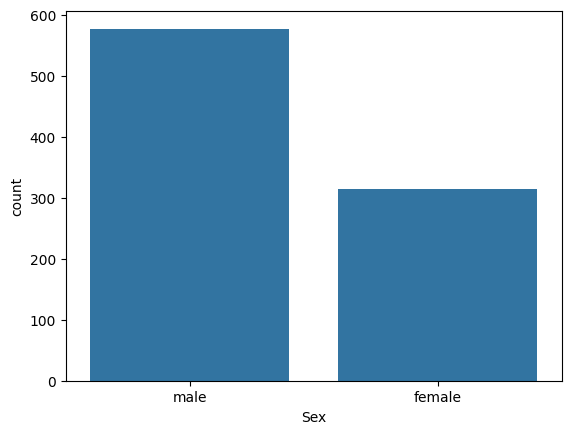

In [48]:
sns.countplot(data =df,x=df['Sex'])

In [49]:
(df['Sex'].value_counts()/len(df))*100

# keyal kore deken ora nijerai sex er element e k koiber ace setar % count kore felse


,count
Sex,
male,64.758698
female,35.241302


<Axes: xlabel='Embarked', ylabel='count'>

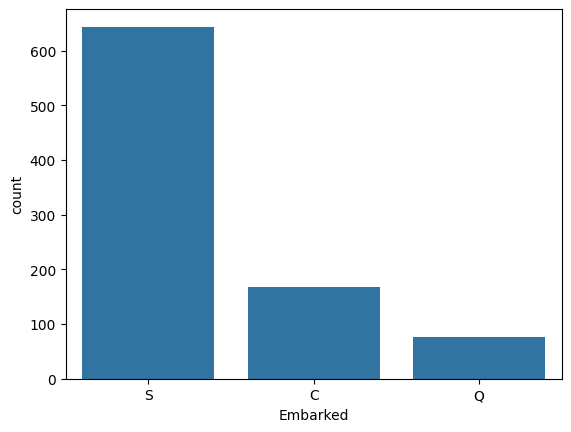

In [50]:
sns.countplot(data = df , x=df['Embarked'])

In [51]:
(df['Embarked'].value_counts() / len(df) ) * 100

,count
Embarked,
S,72.278339
C,18.855219
Q,8.641975


Univariate Analysis(Numercal values)

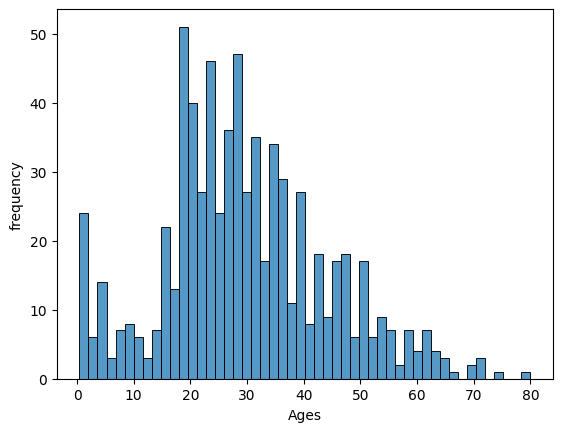

In [56]:
# numerical e maximum e hist plot use kora hoi
sns.histplot(df['Age'],bins=50)
plt.xlabel('Ages')
plt.ylabel('frequency')

# last er onk kicoi acceptable na

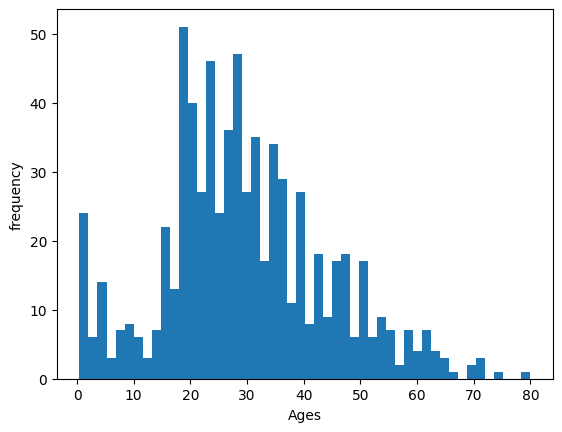

In [57]:

plt.hist(df['Age'],bins=50)
plt.xlabel('Ages')
plt.ylabel('frequency')    # ahamori fresh na agola

plt.show()

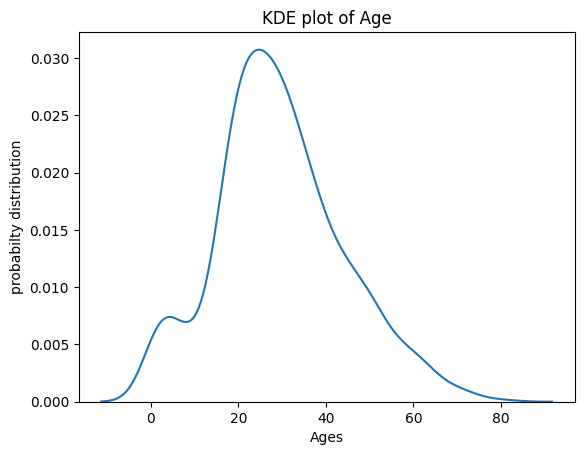

In [59]:
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Ages')
plt.ylabel('probabilty distribution')

plt.show()

part2

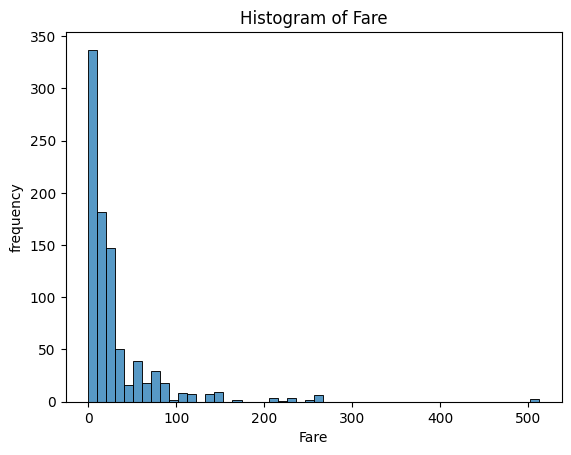

In [61]:
sns.histplot(df['Fare'],bins=50)

plt.title('Histogram of Fare') # fare means akne taka bojano hocce
plt.xlabel('Fare')
plt.ylabel('frequency')

plt.show()

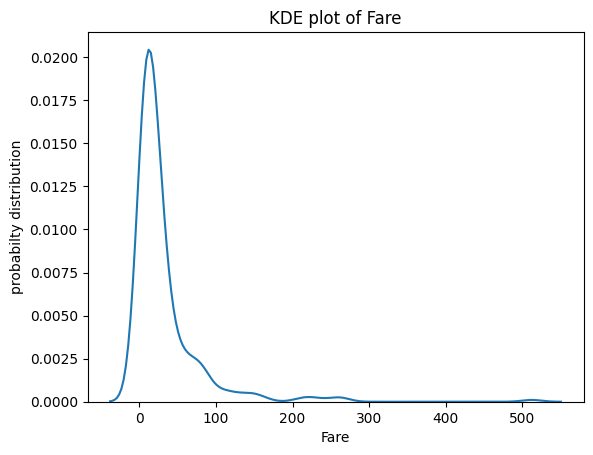

In [62]:
sns.kdeplot(df['Fare'])
plt.title('KDE plot of Fare')
plt.xlabel('Fare')
plt.ylabel('probabilty distribution')

plt.show()

<Axes: ylabel='Fare'>

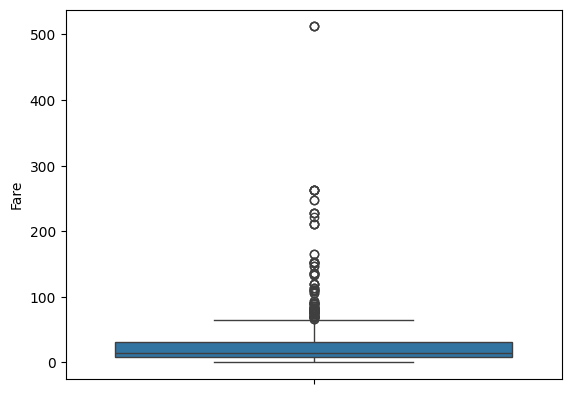

In [63]:
sns.boxplot(df['Fare'])

# nicer line ta minimum oporer line ta maximum
# er oprer gola garbage type dorte paro agolakE IQR korte hbe

<Axes: ylabel='Age'>

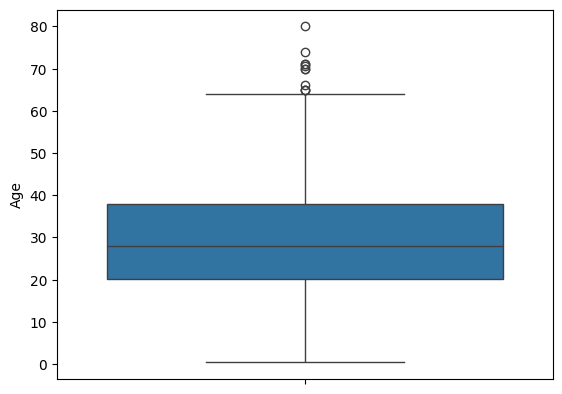

In [64]:
sns.boxplot(df['Age'])